# MovieLens 1M 스트리밍 알고리즘 실험

구현 알고리즘:
- Bloom Filter
- Count-Min Sketch

실험 항목:
- 정확도
- 메모리 사용량
- 처리 시간
- 정확도·메모리 trade-off 분석


In [9]:
from google.colab import files

uploaded = files.upload()

ratings_path = list(uploaded.keys())[0]
print("업로드된 파일:", ratings_path)


Saving ratings.dat to ratings.dat
업로드된 파일: ratings.dat


## 2. 라이브러리 불러오기

In [10]:
import hashlib
import time
import math
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt


## 3. 스트리밍 방식으로 MovieID 읽기

In [11]:
def iter_movie_ids(path):
    """ratings.dat에서 MovieID만 한 줄씩 스트리밍으로 읽는다."""
    with open(path, "r", encoding="latin-1") as f:
        for line in f:
            parts = line.strip().split("::")
            if len(parts) >= 2:
                yield parts[1]


def build_ground_truth(path):
    """정확한 MovieID 빈도를 계산한다."""
    counts = Counter()
    for movie_id in iter_movie_ids(path):
        counts[movie_id] += 1
    return counts


true_counts = build_ground_truth(ratings_path)
true_movie_ids = set(true_counts.keys())

print("총 평점 레코드 수:", sum(true_counts.values()))
print("고유 영화 수:", len(true_movie_ids))
print("상위 10개 영화 빈도:")
print(true_counts.most_common(10))


총 평점 레코드 수: 1000209
고유 영화 수: 3706
상위 10개 영화 빈도:
[('2858', 3428), ('260', 2991), ('1196', 2990), ('1210', 2883), ('480', 2672), ('2028', 2653), ('589', 2649), ('2571', 2590), ('1270', 2583), ('593', 2578)]


## 4. Bloom Filter 구현

In [12]:
class BloomFilter:
    def __init__(self, m_bits, k_hashes):
        self.m = m_bits
        self.k = k_hashes
        self.bits = bytearray((m_bits + 7) // 8)
        self.hash_cache = {}

    def _hashes(self, item):
        if item in self.hash_cache:
            return self.hash_cache[item]

        digest = hashlib.blake2b(item.encode("utf-8"), digest_size=16).digest()
        h1 = int.from_bytes(digest[:8], "little")
        h2 = int.from_bytes(digest[8:], "little")

        values = [((h1 + i * h2) % self.m) for i in range(self.k)]
        self.hash_cache[item] = values
        return values

    def add(self, item):
        for h in self._hashes(item):
            self.bits[h // 8] |= 1 << (h % 8)

    def contains(self, item):
        return all(self.bits[h // 8] & (1 << (h % 8)) for h in self._hashes(item))

    def memory_kb(self):
        return len(self.bits) / 1024


## 5. Count-Min Sketch 구현

In [13]:
class CountMinSketch:
    def __init__(self, width, depth):
        self.width = width
        self.depth = depth
        self.table = [[0] * width for _ in range(depth)]
        self.hash_cache = {}

    def _hashes(self, item):
        if item in self.hash_cache:
            return self.hash_cache[item]

        values = []
        for row in range(self.depth):
            key = row.to_bytes(4, "little")
            digest = hashlib.blake2b(item.encode("utf-8"), key=key, digest_size=8).digest()
            values.append(int.from_bytes(digest, "little") % self.width)

        self.hash_cache[item] = values
        return values

    def add(self, item, count=1):
        for row, col in enumerate(self._hashes(item)):
            self.table[row][col] += count

    def estimate(self, item):
        return min(self.table[row][col] for row, col in enumerate(self._hashes(item)))

    def memory_kb(self):
        # 보고서 기준: counter 1개를 8 bytes로 계산
        return self.width * self.depth * 8 / 1024


## 6. 실험 함수 정의

In [14]:
def run_bloom_filter(path, true_movie_ids, m_bits, k_hashes):
    bf = BloomFilter(m_bits, k_hashes)

    start = time.perf_counter()
    for movie_id in iter_movie_ids(path):
        bf.add(movie_id)
    elapsed = time.perf_counter() - start

    # 실제 존재하지 않는 MovieID 질의 집합 생성
    max_id = max(map(int, true_movie_ids))
    negative_queries = [str(i) for i in range(max_id + 1, max_id + 1 + len(true_movie_ids))]

    false_positive = sum(1 for q in negative_queries if bf.contains(q))
    false_negative = sum(1 for q in true_movie_ids if not bf.contains(q))
    fpr = false_positive / len(negative_queries) * 100

    return {
        "m bits": m_bits,
        "k": k_hashes,
        "False Positive": false_positive,
        "FPR": fpr,
        "False Negative": false_negative,
        "Memory KB": bf.memory_kb(),
        "Time sec": elapsed,
    }


def run_count_min_sketch(path, true_counts, width, depth):
    cms = CountMinSketch(width, depth)

    start = time.perf_counter()
    for movie_id in iter_movie_ids(path):
        cms.add(movie_id)
    elapsed = time.perf_counter() - start

    abs_errors = []
    rel_errors = []

    for movie_id, true_count in true_counts.items():
        estimated = cms.estimate(movie_id)
        abs_error = estimated - true_count
        rel_error = abs_error / true_count * 100

        abs_errors.append(abs_error)
        rel_errors.append(rel_error)

    return {
        "width": width,
        "depth": depth,
        "Mean Abs Error": sum(abs_errors) / len(abs_errors),
        "Mean Rel Error": sum(rel_errors) / len(rel_errors),
        "Max Abs Error": max(abs_errors),
        "Memory KB": cms.memory_kb(),
        "Time sec": elapsed,
    }


## 7. 실험 실행

In [15]:
bloom_params = [
    (50_000, 3),
    (100_000, 3),
    (200_000, 5),
    (400_000, 7),
]

cms_params = [
    (500, 3),
    (1000, 5),
    (2000, 5),
    (4000, 7),
]

bloom_results = []
for m_bits, k in bloom_params:
    print(f"Bloom Filter 실행 중: m={m_bits}, k={k}")
    bloom_results.append(run_bloom_filter(ratings_path, true_movie_ids, m_bits, k))

cms_results = []
for width, depth in cms_params:
    print(f"Count-Min Sketch 실행 중: width={width}, depth={depth}")
    cms_results.append(run_count_min_sketch(ratings_path, true_counts, width, depth))

bf_df = pd.DataFrame(bloom_results)
cms_df = pd.DataFrame(cms_results)

bf_df_display = bf_df.copy()
bf_df_display["FPR"] = bf_df_display["FPR"].map(lambda x: f"{x:.4f}%")
bf_df_display["Memory KB"] = bf_df_display["Memory KB"].map(lambda x: f"{x:.2f} KB")
bf_df_display["Time sec"] = bf_df_display["Time sec"].map(lambda x: f"{x:.3f}")

cms_df_display = cms_df.copy()
cms_df_display["Mean Abs Error"] = cms_df_display["Mean Abs Error"].map(lambda x: f"{x:.3f}")
cms_df_display["Mean Rel Error"] = cms_df_display["Mean Rel Error"].map(lambda x: f"{x:.3f}%")
cms_df_display["Memory KB"] = cms_df_display["Memory KB"].map(lambda x: f"{x:.2f} KB")
cms_df_display["Time sec"] = cms_df_display["Time sec"].map(lambda x: f"{x:.3f}")

print("\nBloom Filter 결과")
display(bf_df_display)

print("\nCount-Min Sketch 결과")
display(cms_df_display)


Bloom Filter 실행 중: m=50000, k=3
Bloom Filter 실행 중: m=100000, k=3
Bloom Filter 실행 중: m=200000, k=5
Bloom Filter 실행 중: m=400000, k=7
Count-Min Sketch 실행 중: width=500, depth=3
Count-Min Sketch 실행 중: width=1000, depth=5
Count-Min Sketch 실행 중: width=2000, depth=5
Count-Min Sketch 실행 중: width=4000, depth=7

Bloom Filter 결과


,m bits,k,False Positive,FPR,False Negative,Memory KB,Time sec
0,50000,3,31,0.8365%,0,6.10 KB,1.359
1,100000,3,3,0.0809%,0,12.21 KB,1.312
2,200000,5,0,0.0000%,0,24.41 KB,1.727
3,400000,7,0,0.0000%,0,48.83 KB,2.202



Count-Min Sketch 결과


,width,depth,Mean Abs Error,Mean Rel Error,Max Abs Error,Memory KB,Time sec
0,500,3,1019.554,6951.859%,4139,11.72 KB,1.458
1,1000,5,203.595,1345.481%,1961,39.06 KB,2.401
2,2000,5,35.506,226.250%,910,78.12 KB,2.282
3,4000,7,0.929,9.459%,307,218.75 KB,1.973


## 8. 그래프 생성

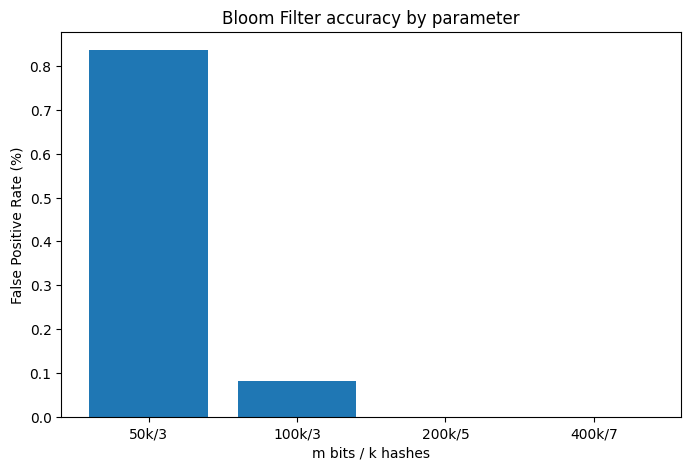

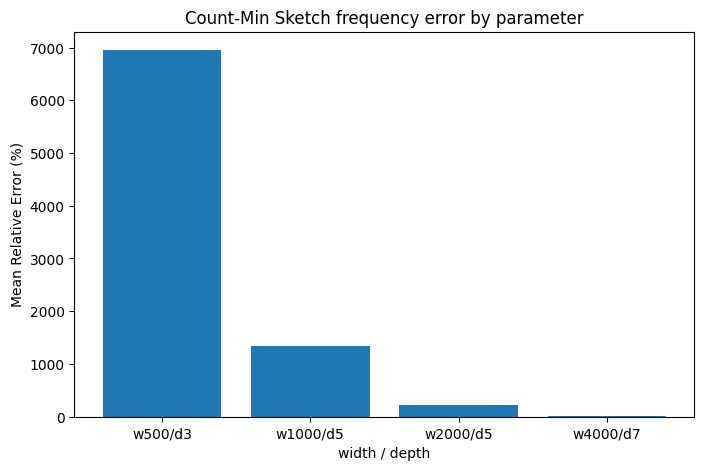

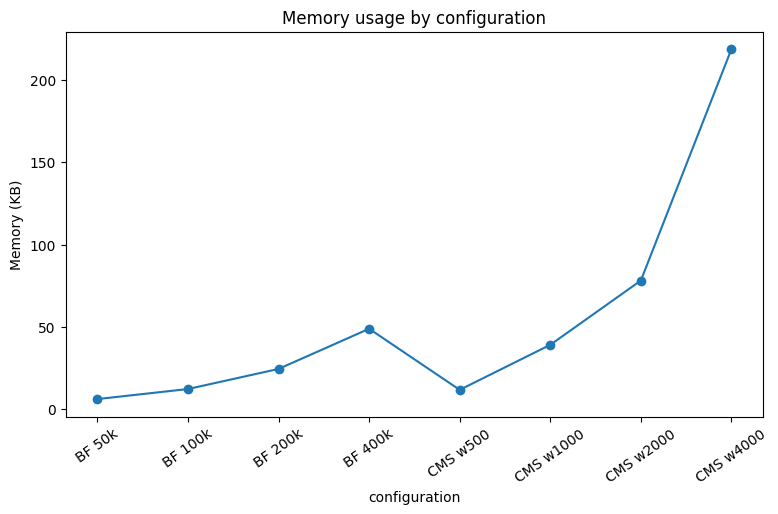

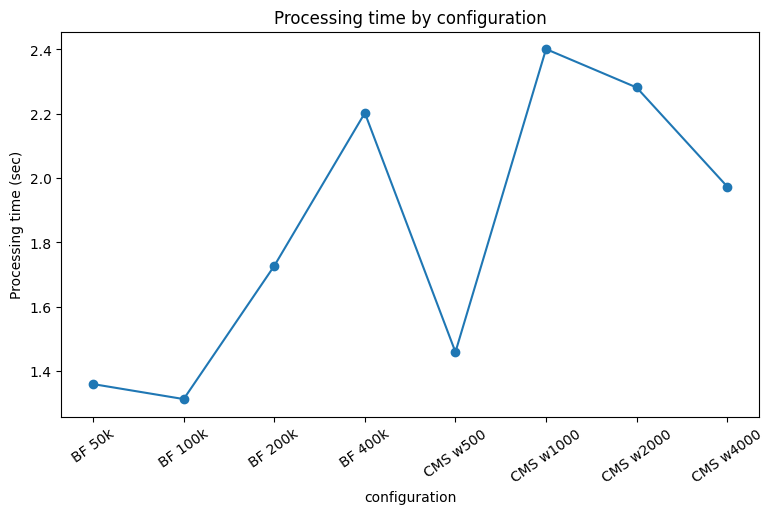

In [16]:
plt.figure(figsize=(8, 5))
plt.bar([f"{m//1000}k/{k}" for m, k in bloom_params], bf_df["FPR"])
plt.title("Bloom Filter accuracy by parameter")
plt.xlabel("m bits / k hashes")
plt.ylabel("False Positive Rate (%)")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar([f"w{w}/d{d}" for w, d in cms_params], cms_df["Mean Rel Error"])
plt.title("Count-Min Sketch frequency error by parameter")
plt.xlabel("width / depth")
plt.ylabel("Mean Relative Error (%)")
plt.show()

memory_labels = (
    [f"BF {m//1000}k" for m, k in bloom_params]
    + [f"CMS w{w}" for w, d in cms_params]
)

memory_values = list(bf_df["Memory KB"]) + list(cms_df["Memory KB"])

plt.figure(figsize=(9, 5))
plt.plot(memory_labels, memory_values, marker="o")
plt.title("Memory usage by configuration")
plt.xlabel("configuration")
plt.ylabel("Memory (KB)")
plt.xticks(rotation=35)
plt.show()

time_labels = memory_labels
time_values = list(bf_df["Time sec"]) + list(cms_df["Time sec"])

plt.figure(figsize=(9, 5))
plt.plot(time_labels, time_values, marker="o")
plt.title("Processing time by configuration")
plt.xlabel("configuration")
plt.ylabel("Processing time (sec)")
plt.xticks(rotation=35)
plt.show()


## 10. 결과 CSV 저장

In [17]:
bf_df.to_csv("bloom_filter_results.csv", index=False)
cms_df.to_csv("count_min_sketch_results.csv", index=False)

print("CSV 저장 완료")
print("bloom_filter_results.csv")
print("count_min_sketch_results.csv")


CSV 저장 완료
bloom_filter_results.csv
count_min_sketch_results.csv
